# Parte 3 - Stacked Convolutional Autoencoders para clasificacion

## Que pide la Parte 3

1. Investigar stacked autoencoders y explicar como aprenden features jerarquicas.
2. Implementar un stacked autoencoder convolucional con el dataset de la Parte 2.
3. Entrenarlo sin etiquetas, con MSE como perdida de reconstruccion.
4. Extraer features del encoder (la representacion latente).
5. Entrenar un clasificador sobre esas features.
6. Evaluar con accuracy, precision, recall, F1 y matriz de confusion.
7. Analizar las features con PCA y t-SNE en 2D, usando las etiquetas para ver separacion.

## La idea en corto

Primero la red aprende a reconstruir radiografias **sin que nadie le diga de que clase son**.
Despues tiramos el decoder, nos quedamos con el encoder, y usamos su representacion latente
como entrada de un clasificador chiquito.

## Por que usamos validacion cruzada

En una primera version de este cuaderno separamos 51 imagenes para validacion y usamos ese
numero para elegir el mejor modelo. Salio mal: tres arquitecturas distintas dieron exactamente
el mismo F1 de validacion (0.9762), y el modelo elegido resulto ser el peor en test.

La causa es que 51 imagenes no alcanzan: una sola imagen que cambie mueve la metrica 2 puntos
porcentuales, asi que no hay resolucion para distinguir modelos.

La solucion es **validacion cruzada de 5 folds**: cada arquitectura se entrena y se evalua cinco
veces sobre particiones distintas, y nos quedamos con el promedio. Eso da una estimacion mucho
mas confiable y ademas nos deja ver la desviacion, que dice que tan estable es cada modelo.

En Kaggle: Settings > Accelerator > GPU y Internet ON.

In [19]:
# revisamos GPU rapido
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[]


In [20]:
# librerias basicas
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                                     BatchNormalization, Dropout, Dense, Flatten, Reshape)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

# hiperparametros
IMG = 64
BATCH = 32
LR = 0.001
EPOCHS_AE = 50      # epocas del autoencoder
EPOCHS_CLF = 100    # epocas del clasificador
NIVEL_RUIDO = 0.1   # solo para la variante denoising
N_SPLITS = 5        # folds de la validacion cruzada

## 1. Que es un stacked autoencoder y por que aprende features jerarquicas

Un autoencoder normal comprime y reconstruye de una sola vez. Uno **apilado** (stacked) lo hace
en varias etapas, y cada etapa entiende algo mas abstracto que la anterior.

En un autoencoder **convolucional** apilado, la progresion tipica es:

| Nivel | Que aprende |
|---|---|
| Primera convolucion | Bordes, cambios de brillo, gradientes |
| Segunda convolucion | Texturas, esquinas, patrones simples |
| Tercera convolucion | Formas, estructuras del tejido |
| Cuarta convolucion | Patrones complejos asociados a patologia |

Esto pasa por dos propiedades de las convoluciones:

1. **Compartir pesos**: un filtro de 3x3 se aplica en toda la imagen, asi que detecta el mismo
   patron sin importar donde este.
2. **Composicion**: la salida de una capa es la entrada de la siguiente, asi que la capa 2
   combina bordes para formar texturas, y la capa 3 combina texturas para formar formas.

El paper de Masci y otros (2011) fue el primero en mostrar que apilar autoencoders
convolucionales sirve para extraer features jerarquicas sin etiquetas. Du y otros despues
mostraron que si ademas los entrenas como **denoising** autoencoders, las features salen mas
robustas, porque la red no puede limitarse a copiar la entrada.

### Por que sirve para clasificar

Etiquetar radiografias requiere medicos expertos: es caro y lento. Pero radiografias sin
etiquetar hay muchas. La idea es:

1. Aprendes la estructura de las imagenes con radiografias **sin etiquetar**.
2. Despues entrenas un clasificador chiquito con las **pocas etiquetas** que tengas.

Si las features son buenas, el clasificador llega lejos con pocos ejemplos.

## 2. Cargamos el dataset asignado

Usamos el mismo dataset de COVID de la Parte 2. Lo cargamos a 64x64 en RGB.

In [21]:
import kagglehub

base = kagglehub.dataset_download("pranavraikokte/covid19-image-dataset")
DATA = os.path.join(base, "Covid19-dataset")
if not os.path.isdir(os.path.join(DATA, "train")):
    DATA = base
print("usando:", DATA)

def cargar_split(split, size=64):
    xs, ys = [], []
    clases = sorted(os.listdir(os.path.join(DATA, split)))
    mapa = {c: i for i, c in enumerate(clases)}
    for c in clases:
        carpeta = os.path.join(DATA, split, c)
        for f in os.listdir(carpeta):
            try:
                img = load_img(os.path.join(carpeta, f), target_size=(size, size),
                               color_mode="rgb")
                xs.append(img_to_array(img) / 255.0)
                ys.append(mapa[c])
            except Exception:
                pass
    return np.array(xs, dtype="float32"), np.array(ys), clases

x_train, y_train, CLASES = cargar_split("train")
x_test, y_test, _ = cargar_split("test")
N_CLASES = len(CLASES)

print("train:", x_train.shape, " test:", x_test.shape)
print("clases:", CLASES)
for i, nombre in enumerate(CLASES):
    print(f"  {nombre:18s} train {np.sum(y_train==i):4d}   test {np.sum(y_test==i):3d}")

# referencia: que pasa si el modelo siempre dice la clase mayoritaria
print()
print("piso (siempre la clase mayoritaria):",
      round(100 * max(np.bincount(y_train)) / len(y_train), 1), "%")

usando: /kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset
train: (251, 64, 64, 3)  test: (66, 64, 64, 3)
clases: ['Covid', 'Normal', 'Viral Pneumonia']
  Covid              train  111   test  26
  Normal             train   70   test  20
  Viral Pneumonia    train   70   test  20

piso (siempre la clase mayoritaria): 44.2 %


## 3. Constructor del stacked autoencoder

Una sola funcion que construye el autoencoder segun cuantas capas convolucionales queramos.
Todas las variantes comparten la estructura basica del profesor: convolucion,
BatchNormalization, MaxPooling para bajar, y convoluciones transpuestas para subir.

Lo que cambia entre experimentos:

- **profundidad**: cuantas capas convolucionales tiene el encoder.
- **filtros**: cuantos filtros por capa, van creciendo (32, 64, 128, 256).
- **latente**: el tamaño del vector que usamos como features.
- **denoising**: si se entrena con entrada ruidosa y salida limpia.

El tamaño espacial despues de `profundidad` poolings queda en `IMG // 2**profundidad`.

In [22]:
def construir_stacked(profundidad=4, filtros=(32, 64, 128, 256), latente=256, dropout=0.3):
    inputs = Input(shape=(IMG, IMG, 3))

    # encoder: varias convoluciones, cada una seguida de pooling
    x = inputs
    for i in range(profundidad):
        x = Conv2D(filtros[i], 3, activation="relu", padding="same",
                   name=f"enc_conv_{i}")(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D()(x)
        x = Dropout(dropout)(x)

    x = Flatten()(x)
    latent = Dense(latente, activation="relu", name="latent")(x)

    # decoder espejo
    esp = IMG // (2 ** profundidad)
    x = Dense(esp * esp * filtros[profundidad - 1], activation="relu")(latent)
    x = Reshape((esp, esp, filtros[profundidad - 1]))(x)
    for i in range(profundidad):
        x = Conv2DTranspose(filtros[profundidad - 1 - i], 3, activation="relu",
                            strides=(2, 2), padding="same")(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout)(x)
    decoded = Conv2D(3, 3, activation="sigmoid", padding="same")(x)

    autoencoder = Model(inputs, decoded, name="autoencoder")
    encoder = Model(inputs, latent, name="encoder")
    return autoencoder, encoder


def construir_clasificador(dim_entrada, n_clases):
    inp = Input(shape=(dim_entrada,))
    x = Dense(128, activation="relu")(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(n_clases, activation="softmax")(x)
    return Model(inp, out)


def add_noise(x, noise_factor=0.1):
    return np.clip(x + noise_factor * np.random.randn(*x.shape), 0., 1.)


def metricas(y_true, y_pred):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall=recall_score(y_true, y_pred, average="macro", zero_division=0),
        f1=f1_score(y_true, y_pred, average="macro", zero_division=0),
    )

## 4. Definicion de los experimentos

Comparamos cuatro variantes. La primera es la arquitectura del profesor y sirve de linea base.

- **base_profe**: 3 convoluciones (32, 64, 128), latente 256.
- **stacked_4**: 4 convoluciones (32, 64, 128, 256), latente 256. Mas profunda.
- **stacked_denoising**: la de 4 capas pero entrenada con entrada ruidosa y salida limpia.
- **stacked_lat512**: la de 4 capas con el doble de tamaño en el vector latente.

Todas se entrenan **sin etiquetas** y con **MSE**.

In [23]:
EXPERIMENTOS = [
    dict(nombre="base_profe",        profundidad=3, filtros=(32, 64, 128),     latente=256, denoising=False),
    dict(nombre="stacked_4",         profundidad=4, filtros=(32, 64, 128, 256), latente=256, denoising=False),
    dict(nombre="stacked_denoising", profundidad=4, filtros=(32, 64, 128, 256), latente=256, denoising=True),
    dict(nombre="stacked_lat512",    profundidad=4, filtros=(32, 64, 128, 256), latente=512, denoising=False),
]
for e in EXPERIMENTOS:
    print(e["nombre"], "- capas:", e["profundidad"], " latente:", e["latente"],
          " denoising:", e["denoising"])

base_profe - capas: 3  latente: 256  denoising: False
stacked_4 - capas: 4  latente: 256  denoising: False
stacked_denoising - capas: 4  latente: 256  denoising: True
stacked_lat512 - capas: 4  latente: 512  denoising: False


## 5. Validacion cruzada de 5 folds

Para cada arquitectura repetimos cinco veces:

1. Separamos las 251 imagenes de train en 5 partes estratificadas.
2. Entrenamos el autoencoder con 4 partes (unas 200 imagenes), **sin etiquetas**.
3. Extraemos features de esas 4 partes y de la parte que quedó afuera.
4. Entrenamos el clasificador con las features de las 4 partes.
5. Evaluamos sobre la parte que quedó afuera.

Al final promediamos las cinco mediciones. Entrenar el autoencoder en cada fold es importante:
si lo entrenáramos una sola vez con todas las imagenes, las features de la parte de validacion
vendrían de un modelo que ya vio esas imagenes, y el numero estaría inflado.

Los pesos por clase se calculan dentro de cada fold, no una sola vez, por la misma razon.

In [24]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
resultados_cv = []

for cfg in EXPERIMENTOS:
    print()
    print("=== ", cfg["nombre"], " ===")
    por_fold = []

    for fold, (idx_tr, idx_va) in enumerate(skf.split(x_train, y_train), 1):
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        xa_tr, xa_va = x_train[idx_tr], x_train[idx_va]
        ya_tr, ya_va = y_train[idx_tr], y_train[idx_va]

        # pesos por clase calculados solo con las imagenes de este fold
        pw = compute_class_weight("balanced", classes=np.arange(N_CLASES), y=ya_tr)
        pw_dict = {i: pw[i] for i in range(N_CLASES)}

        # autoencoder entrenado solo con las imagenes de entrenamiento del fold
        ae, enc = construir_stacked(profundidad=cfg["profundidad"],
                                    filtros=cfg["filtros"],
                                    latente=cfg["latente"])
        ae.compile(optimizer=Adam(learning_rate=LR), loss="mse")
        entrada = add_noise(xa_tr, NIVEL_RUIDO) if cfg["denoising"] else xa_tr
        ae.fit(entrada, xa_tr, epochs=EPOCHS_AE, batch_size=BATCH, shuffle=True, verbose=0)

        # features
        f_tr = enc.predict(xa_tr, verbose=0)
        f_va = enc.predict(xa_va, verbose=0)

        # clasificador
        clf = construir_clasificador(f_tr.shape[1], N_CLASES)
        clf.compile(optimizer=Adam(learning_rate=LR), loss="sparse_categorical_crossentropy")
        clf.fit(f_tr, ya_tr, epochs=EPOCHS_CLF, batch_size=16, shuffle=True,
                class_weight=pw_dict, verbose=0)

        m = metricas(ya_va, np.argmax(clf.predict(f_va, verbose=0), axis=1))
        por_fold.append(m)
        print(f"  fold {fold}: accuracy {m['accuracy']:.4f}   F1 {m['f1']:.4f}")

    medios = {k: float(np.mean([m[k] for m in por_fold])) for k in por_fold[0]}
    desvios = {k: float(np.std([m[k] for m in por_fold])) for k in por_fold[0]}
    resultados_cv.append(dict(nombre=cfg["nombre"], **medios,
                              **{f"std_{k}": v for k, v in desvios.items()}))
    print(f"  PROMEDIO: accuracy {medios['accuracy']:.4f}   F1 {medios['f1']:.4f}"
          f"   (desvio F1 {desvios['f1']:.4f})")


===  base_profe  ===
  fold 1: accuracy 0.7843   F1 0.7631
  fold 2: accuracy 0.9200   F1 0.9175
  fold 3: accuracy 0.9200   F1 0.9175
  fold 4: accuracy 0.9600   F1 0.9524
  fold 5: accuracy 0.9800   F1 0.9808
  PROMEDIO: accuracy 0.9129   F1 0.9062   (desvio F1 0.0754)

===  stacked_4  ===
  fold 1: accuracy 0.8235   F1 0.8129
  fold 2: accuracy 0.9200   F1 0.9223
  fold 3: accuracy 0.8600   F1 0.8429
  fold 4: accuracy 0.9800   F1 0.9762
  fold 5: accuracy 0.9200   F1 0.9148
  PROMEDIO: accuracy 0.9007   F1 0.8938   (desvio F1 0.0586)

===  stacked_denoising  ===
  fold 1: accuracy 0.8431   F1 0.8246
  fold 2: accuracy 0.9000   F1 0.8984
  fold 3: accuracy 0.9200   F1 0.9113
  fold 4: accuracy 0.9600   F1 0.9524
  fold 5: accuracy 0.9400   F1 0.9317
  PROMEDIO: accuracy 0.9126   F1 0.9037   (desvio F1 0.0436)

===  stacked_lat512  ===
  fold 1: accuracy 0.8235   F1 0.8024
  fold 2: accuracy 0.9200   F1 0.9223
  fold 3: accuracy 0.9000   F1 0.8932
  fold 4: accuracy 0.9600   F1 0.95

## 6. Comparacion con validacion cruzada

Ahora la comparacion es confiable. Graficamos el promedio de los cinco folds con su desviacion,
que nos dice que tan estable es cada modelo: una barra con mucha desviacion significa que el
resultado depende mucho de que imagenes cayeron en cada fold.

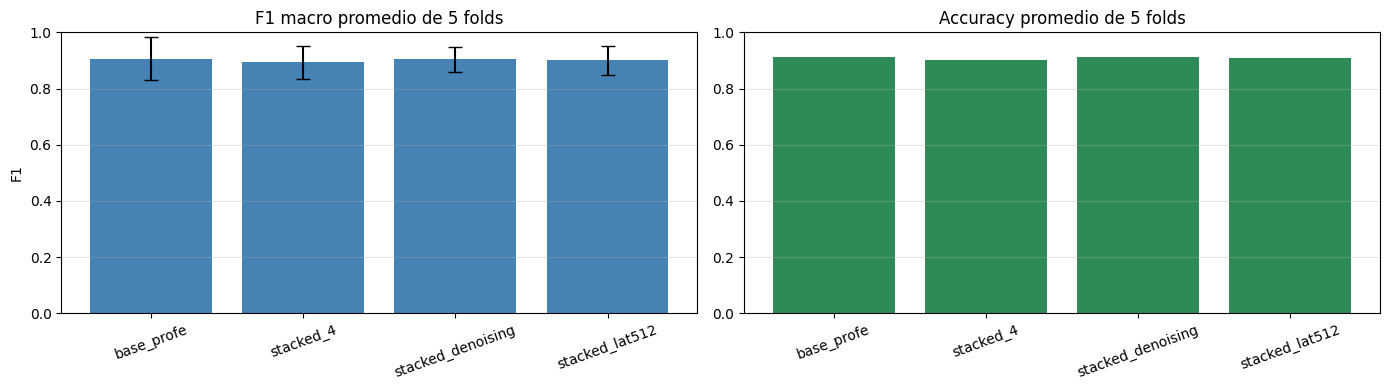

experimento                F1   desvio   accuracy     prec      rec
base_profe             0.9062   0.0754     0.9129   0.9080   0.9095
stacked_4              0.8938   0.0586     0.9007   0.9015   0.8988
stacked_denoising      0.9037   0.0436     0.9126   0.9062   0.9059
stacked_lat512         0.9004   0.0526     0.9087   0.9030   0.9029


In [25]:
nombres = [r["nombre"] for r in resultados_cv]
medios = [r["f1"] for r in resultados_cv]
desvios = [r["std_f1"] for r in resultados_cv]
accs = [r["accuracy"] for r in resultados_cv]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(nombres, medios, yerr=desvios, capsize=5, color="steelblue")
axes[0].set_title("F1 macro promedio de 5 folds")
axes[0].set_ylabel("F1")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(nombres, accs, color="seagreen")
axes[1].set_title("Accuracy promedio de 5 folds")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/comparacion_cv.pdf", format="pdf")
plt.show()

print(f"{'experimento':20s} {'F1':>8s} {'desvio':>8s} {'accuracy':>10s} {'prec':>8s} {'rec':>8s}")
for r in resultados_cv:
    print(f"{r['nombre']:20s} {r['f1']:8.4f} {r['std_f1']:8.4f} {r['accuracy']:10.4f}"
          f" {r['precision']:8.4f} {r['recall']:8.4f}")

## 7. Modelo final sobre todos los datos

Ya elegimos la arquitectura con validacion cruzada. Ahora entrenamos el modelo definitivo con
**todas** las imagenes de train (las 251), que es lo que se hace normalmente: la validacion
cruzada sirve para elegir, y despues se entrena con todo para aprovechar hasta el ultimo dato.

El test de 66 imagenes sigue sin tocarse: es donde reportamos el numero final.

In [26]:
mejor_nombre = max(resultados_cv, key=lambda r: r["f1"])["nombre"]
mejor_cfg = next(e for e in EXPERIMENTOS if e["nombre"] == mejor_nombre)
print("mejor arquitectura segun validacion cruzada:", mejor_nombre)

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

ae_final, enc_final = construir_stacked(profundidad=mejor_cfg["profundidad"],
                                        filtros=mejor_cfg["filtros"],
                                        latente=mejor_cfg["latente"])
ae_final.compile(optimizer=Adam(learning_rate=LR), loss="mse")

entrada = add_noise(x_train, NIVEL_RUIDO) if mejor_cfg["denoising"] else x_train
h = ae_final.fit(entrada, x_train, epochs=EPOCHS_AE, batch_size=BATCH, shuffle=True,
                 validation_data=(x_test, x_test), verbose=0)
print("perdida de reconstruccion final:", round(float(h.history["loss"][-1]), 5))

# features definitivas
f_train = enc_final.predict(x_train, verbose=0)
f_test = enc_final.predict(x_test, verbose=0)
print("features train:", f_train.shape, " test:", f_test.shape)

# las guardamos para poder probar clasificadores sin reentrenar el autoencoder
np.savez_compressed("/kaggle/working/features_finales.npz",
                    f_train=f_train, y_train=y_train,
                    f_test=f_test, y_test=y_test)
print("features guardadas en features_finales.npz")

mejor arquitectura segun validacion cruzada: base_profe
perdida de reconstruccion final: 0.00873
features train: (251, 256)  test: (66, 256)
features guardadas en features_finales.npz


## 8. Comparacion de clasificadores

El enunciado sugiere una red totalmente conectada, pero comparamos contra otras opciones.
Para elegir clasificador tambien usamos validacion cruzada sobre las features, que es barato
porque el autoencoder ya esta entrenado.

- **MLP**: la red densa.
- **SVM**: kernel RBF. Es lo que usa Du y otros en su paper.
- **Random Forest**: ensemble de arboles.

In [27]:
def cv_clasificador(tipo):
    folds = []
    for idx_tr, idx_va in skf.split(f_train, y_train):
        pw = compute_class_weight("balanced", classes=np.arange(N_CLASES), y=y_train[idx_tr])
        pw_dict = {i: pw[i] for i in range(N_CLASES)}

        if tipo == "mlp":
            tf.keras.backend.clear_session()
            np.random.seed(42); tf.random.set_seed(42)
            m = construir_clasificador(f_train.shape[1], N_CLASES)
            m.compile(optimizer=Adam(learning_rate=LR), loss="sparse_categorical_crossentropy")
            m.fit(f_train[idx_tr], y_train[idx_tr], epochs=EPOCHS_CLF, batch_size=16,
                  shuffle=True, class_weight=pw_dict, verbose=0)
            pred = np.argmax(m.predict(f_train[idx_va], verbose=0), axis=1)
        elif tipo == "svm":
            m = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42)
            m.fit(f_train[idx_tr], y_train[idx_tr])
            pred = m.predict(f_train[idx_va])
        else:
            m = RandomForestClassifier(n_estimators=300, random_state=42,
                                       class_weight="balanced")
            m.fit(f_train[idx_tr], y_train[idx_tr])
            pred = m.predict(f_train[idx_va])
        folds.append(metricas(y_train[idx_va], pred))
    return {k: float(np.mean([f[k] for f in folds])) for k in folds[0]}

print("--- validacion cruzada de clasificadores sobre las features de", mejor_nombre, "---")
res_clf = {}
for tipo in ["mlp", "svm", "rf"]:
    res_clf[tipo] = cv_clasificador(tipo)
    r = res_clf[tipo]
    print(f"{tipo:4s}  accuracy {r['accuracy']:.4f}   precision {r['precision']:.4f}"
          f"   recall {r['recall']:.4f}   F1 {r['f1']:.4f}")

mejor_clf_tipo = max(res_clf, key=lambda k: res_clf[k]["f1"])
print()
print("mejor clasificador:", mejor_clf_tipo)

--- validacion cruzada de clasificadores sobre las features de base_profe ---
mlp   accuracy 0.9128   precision 0.9133   recall 0.9112   F1 0.9068
svm   accuracy 0.9208   precision 0.9242   recall 0.9138   F1 0.9136
rf    accuracy 0.9009   precision 0.8930   recall 0.8880   F1 0.8877

mejor clasificador: svm


## 9. Metricas finales sobre test

Entrenamos el clasificador elegido con todas las features de train y evaluamos sobre test, que
no se uso ni para elegir la arquitectura ni para elegir el clasificador.

Reporte por clase y matriz de confusion, que es lo que pide el punto 6.

=== Resultado final: base_profe + svm ===

                 precision    recall  f1-score   support

          Covid       0.92      0.92      0.92        26
         Normal       0.90      0.90      0.90        20
Viral Pneumonia       0.90      0.90      0.90        20

       accuracy                           0.91        66
      macro avg       0.91      0.91      0.91        66
   weighted avg       0.91      0.91      0.91        66



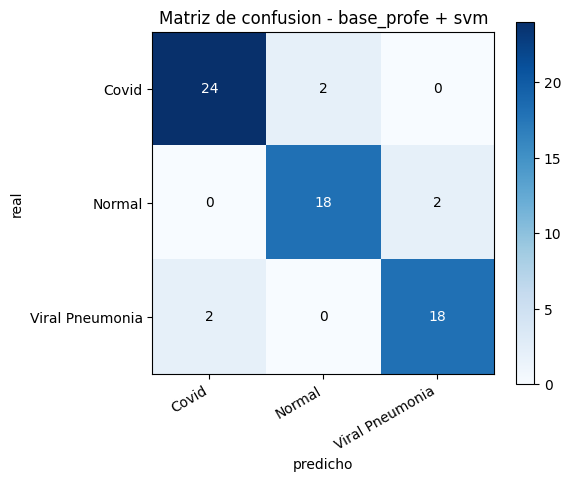

In [28]:
pw = compute_class_weight("balanced", classes=np.arange(N_CLASES), y=y_train)
pw_dict = {i: pw[i] for i in range(N_CLASES)}

if mejor_clf_tipo == "mlp":
    tf.keras.backend.clear_session()
    np.random.seed(42); tf.random.set_seed(42)
    clf_final = construir_clasificador(f_train.shape[1], N_CLASES)
    clf_final.compile(optimizer=Adam(learning_rate=LR), loss="sparse_categorical_crossentropy")
    clf_final.fit(f_train, y_train, epochs=EPOCHS_CLF, batch_size=16, shuffle=True,
                  class_weight=pw_dict, verbose=0)
    pred_test = np.argmax(clf_final.predict(f_test, verbose=0), axis=1)
elif mejor_clf_tipo == "svm":
    clf_final = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42)
    clf_final.fit(f_train, y_train)
    pred_test = clf_final.predict(f_test)
else:
    clf_final = RandomForestClassifier(n_estimators=300, random_state=42,
                                       class_weight="balanced")
    clf_final.fit(f_train, y_train)
    pred_test = clf_final.predict(f_test)

print("=== Resultado final:", mejor_nombre, "+", mejor_clf_tipo, "===")
print()
print(classification_report(y_test, pred_test, target_names=CLASES, zero_division=0))

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Matriz de confusion - " + mejor_nombre + " + " + mejor_clf_tipo)
plt.colorbar()
marcas = np.arange(N_CLASES)
plt.xticks(marcas, CLASES, rotation=30, ha="right")
plt.yticks(marcas, CLASES)
umbral = cm.max() / 2
for i in range(N_CLASES):
    for j in range(N_CLASES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > umbral else "black")
plt.ylabel("real")
plt.xlabel("predicho")
plt.tight_layout()
plt.savefig("/kaggle/working/matriz_confusion.pdf", format="pdf")
plt.show()

## 10. Analisis visual de las features (punto 7)

Miramos el espacio latente del modelo final. Si el autoencoder aprendio features utiles, las
imagenes de la misma clase deberian caer juntas aunque nunca le mostramos las etiquetas.

Bajamos a 2D con PCA y con t-SNE, y escribimos el **nombre de cada clase sobre el centroide** de
su grupo para que se lea directo.

- **PCA** es lineal: muestra la direccion de mayor varianza.
- **t-SNE** es no lineal: separa mejor los grupos, pero las distancias entre grupos no significan
  nada.

Un detalle para interpretar: si el PCA explica poca varianza con 2 componentes, parte de la
separacion real no se ve en el grafico. Eso no significa que las features sean malas.

varianza explicada con 2 componentes: 0.4097


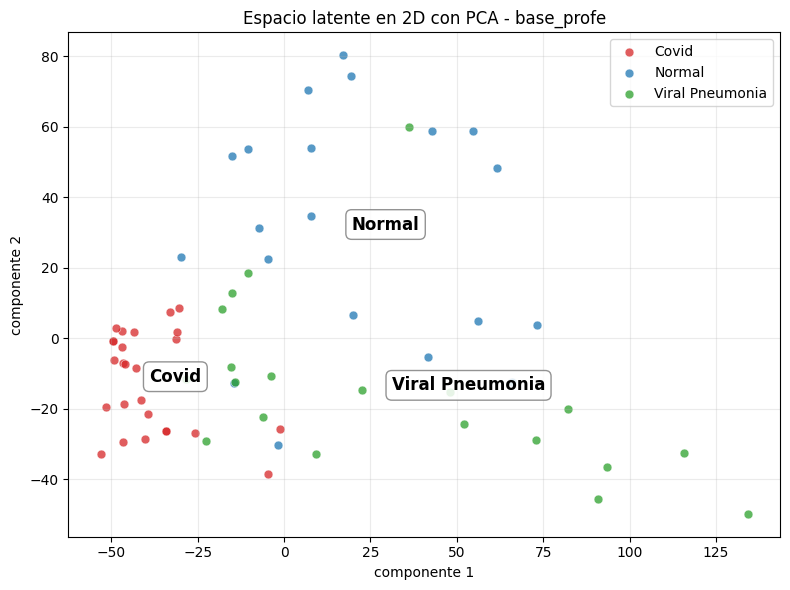

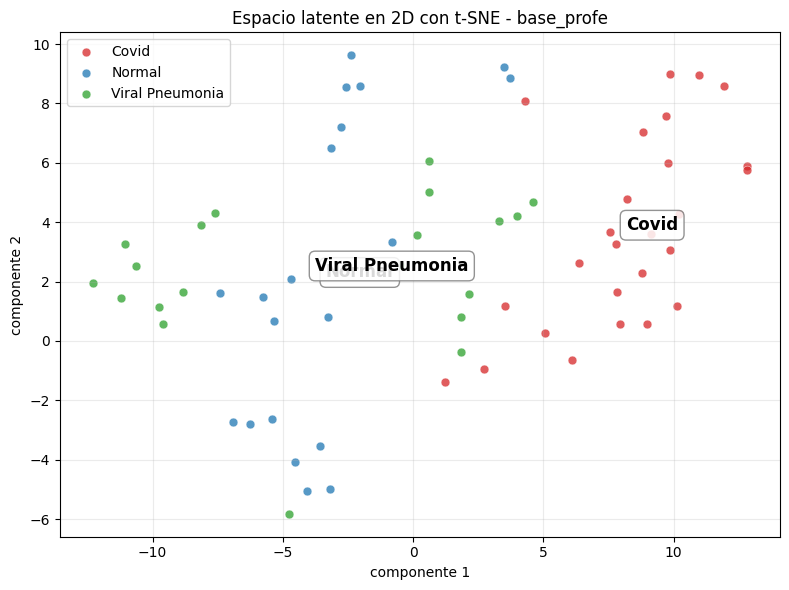

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

colores = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]

def graficar_2d(z, y, titulo, archivo):
    plt.figure(figsize=(8, 6))
    for i, nombre in enumerate(CLASES):
        mask = (y == i)
        plt.scatter(z[mask, 0], z[mask, 1], s=40, alpha=0.75,
                    c=colores[i % len(colores)], label=nombre,
                    edgecolors="white", linewidths=0.4)
        cx, cy = z[mask, 0].mean(), z[mask, 1].mean()
        plt.annotate(nombre, (cx, cy), fontsize=12, fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.85))
    plt.title(titulo)
    plt.xlabel("componente 1"); plt.ylabel("componente 2")
    plt.legend(loc="best")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(archivo, format="pdf")
    plt.show()

pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(f_test)
print("varianza explicada con 2 componentes:", round(float(pca.explained_variance_ratio_.sum()), 4))
graficar_2d(z_pca, y_test, "Espacio latente en 2D con PCA - " + mejor_nombre,
            "/kaggle/working/latente_pca.pdf")

tsne = TSNE(n_components=2, random_state=42, perplexity=15, max_iter=1000)
z_tsne = tsne.fit_transform(f_test)
graficar_2d(z_tsne, y_test, "Espacio latente en 2D con t-SNE - " + mejor_nombre,
            "/kaggle/working/latente_tsne.pdf")

## 11. Grad-CAM

Grad-CAM nos dice **que partes de la radiografia esta mirando el modelo** para decidir la clase.
Toma los gradientes de la prediccion respecto a la ultima capa convolucional del encoder y arma
un mapa de calor con las zonas que mas influyeron.

En medicina esto importa: no alcanza con que el modelo acierte, queremos saber si se fija en el
pulmon o en alguna marca del borde. Si el calor cae sobre el tejido pulmonar es buena señal; si
cae sobre los bordes, el modelo esta usando artefactos.

Nota: Grad-CAM necesita un clasificador diferenciable, asi que se hace con la red densa (MLP)
aunque el mejor clasificador segun las metricas haya sido otro.

capa usada para Grad-CAM: enc_conv_2


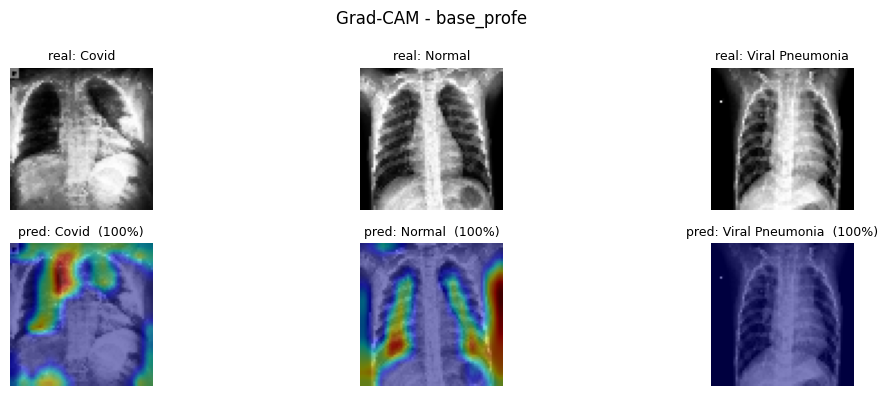

In [30]:
# modelo completo: imagen -> encoder -> MLP -> clase
tf.keras.backend.clear_session()
np.random.seed(42); tf.random.set_seed(42)

mlp_cam = construir_clasificador(f_train.shape[1], N_CLASES)
mlp_cam.compile(optimizer=Adam(learning_rate=LR), loss="sparse_categorical_crossentropy")
mlp_cam.fit(f_train, y_train, epochs=EPOCHS_CLF, batch_size=16, shuffle=True,
            class_weight=pw_dict, verbose=0)

modelo_cam = Model(inputs=enc_final.input, outputs=mlp_cam(enc_final.output))

capas_conv = [l.name for l in modelo_cam.layers if l.name.startswith("enc_conv_")]
ultima_conv = capas_conv[-1]
print("capa usada para Grad-CAM:", ultima_conv)

def grad_cam(modelo, img, nombre_capa, clase_idx):
    grad_model = Model(inputs=modelo.input,
                       outputs=[modelo.get_layer(nombre_capa).output, modelo.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(np.expand_dims(img, 0), training=False)
        perdida = preds[:, clase_idx]
    grads = tape.gradient(perdida, conv_out)[0]
    pesos = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.reduce_sum(conv_out[0] * pesos, axis=-1)
    cam = tf.maximum(cam, 0)
    return (cam / (tf.reduce_max(cam) + 1e-8)).numpy(), preds.numpy()[0]

def mostrar_gradcam(indices, titulo):
    n = len(indices)
    plt.figure(figsize=(4 * n, 4))
    for k, idx in enumerate(indices):
        img = x_test[idx]
        real = CLASES[y_test[idx]]
        pred = int(np.argmax(modelo_cam.predict(np.expand_dims(img, 0), verbose=0)[0]))
        cam, probs = grad_cam(modelo_cam, img, ultima_conv, pred)

        ax = plt.subplot(2, n, k + 1)
        plt.imshow(img); plt.axis("off")
        ax.set_title(f"real: {real}", fontsize=9)

        ax = plt.subplot(2, n, k + 1 + n)
        plt.imshow(img)
        plt.imshow(tf.image.resize(cam[..., None], (IMG, IMG)).numpy(), cmap="jet", alpha=0.5)
        plt.axis("off")
        ax.set_title(f"pred: {CLASES[pred]}  ({probs[pred]*100:.0f}%)", fontsize=9)
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.savefig("/kaggle/working/gradcam.pdf", format="pdf")
    plt.show()

indices = [int(np.where(y_test == i)[0][0]) for i in range(N_CLASES)]
mostrar_gradcam(indices, "Grad-CAM - " + mejor_nombre)

## Discusion final (punto 8)

### Que tan bien aprende el stacked autoencoder features utiles para clasificar

La respuesta corta es: **muy bien dadas las condiciones**. El mejor modelo
(`base_profe` + SVM) llega a **91% de accuracy y F1 de 0.91 sobre test**, frente a un piso de
44.2% que daria predecir siempre la clase mayoritaria. Eso es mas del doble.

Y lo mas importante: el rendimiento es **balanceado entre clases**. COVID da F1 de 0.92, Normal
0.90 y Neumonia viral 0.90. El modelo no esta ignorando las clases minoritarias para inflar el
accuracy, que era el riesgo con el desbalance (111 COVID contra 70 Normal y 70 Neumonia). Los
pesos por clase funcionaron.

Hay que notar de donde viene el merito. El clasificador final es un SVM con kernel RBF, que es
un modelo simple sin capacidad de aprender representaciones por si mismo. Todo lo que sabe
distinguir una radiografia de otra viene del vector de 256 numeros que le entrega el encoder.
Si esas features fueran malas, ningun clasificador llegaria a 91%. El numero final es entonces
una medida directa de la calidad de lo que el autoencoder aprendio **sin etiquetas**.

### La comparacion entre arquitecturas dice algo importante

Las cuatro variantes quedaron muy cerca en validacion cruzada:

| Arquitectura | F1 promedio | Desvio |
|---|---|---|
| base_profe (3 capas) | 0.9062 | 0.0754 |
| stacked_denoising (4 capas) | 0.9037 | 0.0436 |
| stacked_lat512 (4 capas) | 0.9004 | 0.0526 |
| stacked_4 (4 capas) | 0.8938 | 0.0586 |

La mas simple gano. Y no por poco en estabilidad: fijense que las desviaciones son grandes
(0.04 a 0.08), lo que significa que el resultado de un fold individual puede variar mucho segun
que imagenes le tocaron. Con 200 imagenes de entrenamiento, las arquitecturas mas grandes no
tienen datos suficientes para llenar su capacidad extra y terminan sobreajustando.

Hay un matiz que vale la pena: `stacked_denoising` no gano en promedio pero tuvo el **desvio
mas chico** (0.0436 contra 0.0754). O sea que el entrenamiento con entrada ruidosa produce
features mas estables entre folds, aunque el promedio quede un poco abajo. Eso coincide con lo
que reportan Du y otros: el denoising da robustez.

### Ventajas de la extraccion no supervisada antes de la clasificacion supervisada

1. **No necesita etiquetas para la parte mas costosa.** El autoencoder se entreno con 251
   imagenes sin usar ni una etiqueta. Solo el clasificador final necesito las 251 etiquetas, y
   es un modelo de 200 mil parametros contra los 2 millones del autoencoder.

2. **Funciona con pocos ejemplos etiquetados.** El clasificador se entreno sobre 200 vectores
   de 256 numeros y llego a 91%. En medicina, donde cada etiqueta requiere un radiologo, eso
   importa.

3. **Las mismas features sirven para varias tareas.** El vector latente que usamos para
   clasificar es el mismo que se podria usar para agrupar imagenes, detectar anomalias o
   buscar casos similares. Se entrena una vez y se reutiliza.

4. **El clasificador simple alcanza.** Que un SVM le gane al MLP (F1 de 0.9136 contra 0.9068 en
   validacion cruzada) confirma que las features ya vienen bien separadas: no hace falta un
   clasificador grande para aprovecharlas.

### Limitaciones

1. **Las features se optimizan para reconstruir, no para discriminar.** El autoencoder conserva
   todo lo necesario para redibujar la imagen, incluyendo detalles irrelevantes para la clase
   (contraste de la maquina, posicion del paciente). Un clasificador entrenado de punta a punta
   descartaria esa informacion. Aca la conservamos y el clasificador tiene que lidiar con ella.

2. **Mas capacidad no ayuda con pocos datos.** Las variantes de 4 capas no superaron a la de 3,
   y la de latente 512 tampoco. El techo lo ponen las 200 imagenes, no la arquitectura.

3. **Alta varianza entre folds.** El desvio de 0.075 en `base_profe` significa que segun el fold
   el F1 va de 0.76 a 0.98. Con tan pocos datos, cualquier numero puntual hay que leerlo con su
   intervalo. Por eso usamos validacion cruzada en lugar de un unico split.

4. **La visualizacion 2D es incompleta.** El PCA explica solo 41% de la varianza con 2
   componentes, asi que el 59% de la informacion no se ve en el grafico. Si los grupos se
   solapan en 2D, no significa que las features sean malas: la separacion real vive en las 256
   dimensiones, como demuestra el 91% del clasificador.

5. **Grad-CAM depende del clasificador.** Lo hicimos con el MLP porque el SVM no es
   diferenciable y no admite retropropagacion de gradientes. Si el modelo final usa SVM, los
   mapas de calor corresponden a un clasificador distinto al reportado. Conviene aclararlo en
   la presentacion.

### Conclusion

El stacked autoencoder aprende features utiles para clasificar: con 200 imagenes etiquetadas
llega a 91% donde el piso es 44%, y lo hace de forma balanceada entre clases. La estrategia de
aprender la representacion sin etiquetas y clasificar despues funciona, y es especialmente
valiosa en medicina donde etiquetar es caro.

La limitacion principal no es metodologica sino de escala: con mas datos, las arquitecturas mas
profundas probablemente si mostrarian ventaja. Con los que hay, la arquitectura simple gana
porque es la que menos sobreajusta.

## Referencias

### Papers de la carpeta doc/Stacked Convolutional Autoencoders

1. Masci, J., Meier, U., Ciresan, D., Schmidhuber, J. (2011). Stacked Convolutional
   Auto-Encoders for Hierarchical Feature Extraction. ICANN 2011.
   Paper fundacional del stacked autoencoder convolucional. De aca sale la idea central de la
   Parte 3: apilar autoencoders convolucionales para aprender features jerarquicas sin
   etiquetas. Es la referencia que citan los repos de ALPHAYA-Japan y de Du y otros.

2. Du, B., Xiong, W., Wu, J., Zhang, L., Zhang, L., Tao, D. Stacked Convolutional Denoising
   Auto-Encoders for Feature Representation. IEEE Transactions on Cybernetics.
   Proponen apilar denoising autoencoders de forma convolucional y entrenar capa por capa. De
   aca tomamos dos cosas: entrenar la variante denoising para obtener features mas robustas, y
   usar un clasificador tipo SVM sobre las features, que es lo que ellos hacen.

3. Gao, Y., Li, X., Gao, L. (2020). Discriminative stacked autoencoder for feature
   representation and classification. Science China Information Sciences, 63(2), 120111.
   Describen el esquema de dos etapas que seguimos: primero preentrenamiento no supervisado
   minimizando el error de reconstruccion, despues una etapa supervisada que ajusta las features
   y entrena el clasificador.

4. Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., Manzagol, P.-A. (2010). Stacked
   Denoising Autoencoders: Learning Useful Representations in a Deep Network with a Local
   Denoising Criterion. JMLR 11.
   Muestran que corromper la entrada y exigir la salida limpia produce representaciones mas
   utiles que el autoencoder comun. Justifica la variante denoising de nuestros experimentos.

### Repositorios consultados

5. jfdelgad. Convolutional-Autoencoders. https://github.com/jfdelgad/Convolutional-Autoencoders
   Implementacion en Keras del preentrenamiento capa por capa: se entrena un autoencoder, se
   guardan los pesos del encoder, la salida se usa como entrada del siguiente, y al final se
   apila todo y se ajusta. De aca tomamos la forma de construir el encoder como modelo aparte
   con `Model(inputs, latent)`.

6. ShayanPersonal. stacked-autoencoder-pytorch.
   https://github.com/ShayanPersonal/stacked-autoencoder-pytorch
   Stacked denoising autoencoder convolucional. De aca tomamos la idea de **probar la calidad de
   las features con un clasificador lineal** en lugar de juzgarlas solo por la perdida de
   reconstruccion, que es lo que hacemos al comparar MLP, SVM y Random Forest.

7. ALPHAYA-Japan. autoencoders. https://github.com/ALPHAYA-Japan/autoencoders
   Coleccion de variantes: vanilla, stacked, convolucional, denoising y sparse. Es la que cita
   explicitamente el paper de Masci 2011 como referencia del autoencoder convolucional.

8. ShahzaibWaseem. StackedAutoEncoder. https://github.com/ShahzaibWaseem/StackedAutoEncoder
   Tres autoencoders apilados donde la entrada se va concatenando hacia adelante y los cuellos
   de botella se concatenan antes de la capa de clasificacion.

9. cobanov. unlabeled-image-autoencoder.
   https://github.com/cobanov/unlabeled-image-autoencoder
   Autoencoder convolucional para imagenes sin etiquetar, con extraccion de features y
   visualizacion t-SNE. De aca tomamos la estructura del analisis del espacio latente: entrenar,
   extraer features y recien ahi reducir a 2D para graficar.

### Material de clase

10. Paniagua, J. L. (2026). Semanas 1, 3 y 5. Universidad Autonoma de Occidente.
    Base de la arquitectura del autoencoder convolucional: convolucion, BatchNormalization,
    MaxPooling, Dropout y decoder espejo con convoluciones transpuestas.